# TSMC 2330.TW stock prediction
## 學號：314833005 姓名：李郡益
## Phase2 特徵說明

| # | 特徵 | 正規化方式 | 意義 |
|---|------|-----------|------|
| 0 | **Close** | log_return z-score | 主要預測目標 |
| 1 | **RSI-14** | ÷100 | 超買/超賣動能 |
| 2 | **MACD** | StandardScaler | 中短期趨勢 |
| 3 | **Volume_ratio** | clip(0,5) + MinMax | 量能強弱 |
| 4 | **Price_range** | clip(0,0.2) + MinMax | 當日波動幅度 |
| 5 | **Open_gap** | clip(±10%) + StandardScaler | 隔夜跳空率 |
| 6 | **Week_trend** | clip(±15%) + StandardScaler | 過去一週趨勢強弱 |

**Open_gap = ln(Open_t / Close_{t-1})**：捕捉開盤跳空訊號，是次日走勢最直接的先行指標。

**Week_trend = ln(Close_t / Close_{t-5})**：擷取最近一週上升/下跌慣性，強化近期空頭或反彈趨勢判斷。


## Step 1：安裝必要套件

In [1]:
# pip install yfinance torch scikit-learn matplotlib pandas numpy

## Step 2：匯入套件 & 固定隨機種子

In [2]:
import os, random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import datetime, timedelta

# ── 固定隨機種子 ──────────────────────────────────────────
SEED = 7
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Random seed fixed: {SEED}')
print(f'Using device: {DEVICE}')

Random seed fixed: 7
Using device: cuda


## Step 3：抓取股票資料

In [3]:
def fetch_stock_data(ticker):
    end_date   = datetime.now()
    start_date = end_date - timedelta(days=10*365)
    try:
        data = yf.Ticker(ticker).history(
            start=start_date.strftime('%Y-%m-%d'),
            end=end_date.strftime('%Y-%m-%d'),
            interval='1d'
        )
        if data.empty:
            print(f'No data found for {ticker}')
        else:
            print(f'Fetched {len(data)} rows for {ticker}')
        return data
    except Exception as e:
        print(f'Error: {e}')
        return pd.DataFrame()

# ── 載入 / 更新 CSV ───────────────────────────────────────
ticker_symbol = '2330.TW'
CSV_FILE      = f"{ticker_symbol.replace('.TW','')}_stock_data.csv"

if not os.path.exists(CSV_FILE):
    stock_data = fetch_stock_data(ticker_symbol)
    if not stock_data.empty:
        stock_data.to_csv(CSV_FILE)
        print(f'首次建立：{CSV_FILE}  ({len(stock_data)} 筆)')
else:
    existing  = pd.read_csv(CSV_FILE, index_col='Date', parse_dates=True)
    last_date = existing.index[-1]
    start     = (last_date + timedelta(days=1)).strftime('%Y-%m-%d')
    end       = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
    new_data  = yf.Ticker(ticker_symbol).history(start=start, end=end, interval='1d')
    if new_data.empty:
        print(f'無新資料，最新：{last_date.date()}，共 {len(existing)} 筆')
    else:
        new_data.index = new_data.index.tz_convert('Asia/Taipei')
        combined = pd.concat([existing, new_data[~new_data.index.isin(existing.index)]])
        combined.to_csv(CSV_FILE)
        print(f'新增 {len(new_data)} 筆，共 {len(combined)} 筆')
    print(f'資料檔：{CSV_FILE}')

stock_df = pd.read_csv(CSV_FILE, index_col='Date', parse_dates=True)
print(f'\n資料筆數：{len(stock_df)}，欄位：{list(stock_df.columns)}')
stock_df.head()

新增 1 筆，共 2430 筆
資料檔：2330_stock_data.csv

資料筆數：2430，欄位：['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-04-06 00:00:00+08:00,117.655435,118.033748,116.142181,116.142181,58134000,0.0,0.0
2016-04-07 00:00:00+08:00,117.277125,117.277125,115.385558,116.898811,35238000,0.0,0.0
2016-04-08 00:00:00+08:00,116.520515,119.547022,116.520515,119.168709,41032000,0.0,0.0
2016-04-11 00:00:00+08:00,118.033764,120.303644,117.655451,119.925331,21758000,0.0,0.0
2016-04-12 00:00:00+08:00,119.168704,120.681958,119.168704,119.925331,14859000,0.0,0.0


## Step 4：特徵工程 — 計算技術指標

In [4]:
def compute_rsi(series, period=14):
    """相對強弱指數 RSI，值域 0-100"""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / (avg_loss + 1e-10)
    return 100 - 100 / (1 + rs)

def compute_macd(series, fast=12, slow=26):
    """MACD 線（EMA12 - EMA26）"""
    return series.ewm(span=fast, adjust=False).mean() - series.ewm(span=slow, adjust=False).mean()

# ── 建立特徵 DataFrame ────────────────────────────────────────────
df = stock_df[['Open', 'Close', 'High', 'Low', 'Volume']].copy()

# 1. RSI-14
df['RSI14']        = compute_rsi(df['Close'], period=14)

# 2. MACD
df['MACD']         = compute_macd(df['Close'])

# 3. 成交量比率：當日量 / 20日均量
df['Vol_MA20']     = df['Volume'].rolling(20).mean()
df['Volume_ratio'] = df['Volume'] / (df['Vol_MA20'] + 1e-10)

# 4. 當日振幅率 (High-Low)/Close
df['Price_range']  = (df['High'] - df['Low']) / (df['Close'] + 1e-10)

# 5. 隔夜跳空率：ln(Open_t / Close_{t-1})
df['Open_gap'] = np.log(df['Open'] / (df['Close'].shift(1) + 1e-10))

# 6. 一週趨勢：ln(Close_t / Close_{t-5})
df['Week_trend'] = np.log(df['Close'] / (df['Close'].shift(5) + 1e-10))

# 丟掉輔助欄位與 NaN
df.drop(columns=['Open', 'High', 'Low', 'Volume', 'Vol_MA20'], inplace=True)
df.dropna(inplace=True)

print(f'特徵欄位：{list(df.columns)}')
print(f'有效資料筆數：{len(df)}')
df.head()


特徵欄位：['Close', 'RSI14', 'MACD', 'Volume_ratio', 'Price_range', 'Open_gap', 'Week_trend']
有效資料筆數：2411


,Close,RSI14,MACD,Volume_ratio,Price_range,Open_gap,Week_trend
Date,,,,,,,
2016-05-04 00:00:00+08:00,111.224113,28.063375,-0.983648,1.440527,0.017007,-0.003396,-0.072162
2016-05-05 00:00:00+08:00,111.602432,30.122717,-1.250012,1.069561,0.016949,0.003396,-0.059228
2016-05-06 00:00:00+08:00,111.980759,32.212595,-1.414276,1.018589,0.010135,0.006757,-0.033225
2016-05-09 00:00:00+08:00,111.602432,31.207452,-1.557037,1.077332,0.016949,0.003373,-0.016807
2016-05-10 00:00:00+08:00,111.224113,30.192881,-1.681321,0.824673,0.010204,-0.003396,-0.003396


## Step 5：正規化（各特徵獨立正規化）

- `Close` → log_return z-score（用來穩定序列尺度）
- `RSI14` → 除以 100（本身 0-100）
- `MACD` → StandardScaler（可正可負，無固定範圍）
- `Volume_ratio` → clip(0, 5) 再 MinMax
- `Price_range` → clip(0, 0.2) 再 MinMax
- `Open_gap` → clip(±10%) 再 StandardScaler
- `Week_trend` → clip(±15%) 再 StandardScaler

In [5]:
# ── 特徵整合（正規化延後到 split 之後）────────────────────────────
# 欄位順序（固定，normalize_set 依 index 存取）：
#   0: Close  1: RSI14  2: MACD  3: Volume_ratio  4: Price_range  5: Open_gap  6: Week_trend

raw_feat = pd.DataFrame(index=df.index)
raw_feat['Close']        = df['Close'].values
raw_feat['RSI14']        = df['RSI14'].values
raw_feat['MACD']         = df['MACD'].values
raw_feat['Volume_ratio'] = df['Volume_ratio'].clip(0, 5).values
raw_feat['Price_range']  = df['Price_range'].clip(0, 0.2).values
raw_feat['Open_gap']     = df['Open_gap'].clip(-0.1, 0.1).values
raw_feat['Week_trend']   = df['Week_trend'].clip(-0.15, 0.15).values

N_FEATURES = raw_feat.shape[1]
print(f'特徵欄位：{list(raw_feat.columns)}')
print(f'有效資料筆數：{len(raw_feat)}  特徵數：{N_FEATURES}')
raw_feat.head()


特徵欄位：['Close', 'RSI14', 'MACD', 'Volume_ratio', 'Price_range', 'Open_gap', 'Week_trend']
有效資料筆數：2411  特徵數：7


,Close,RSI14,MACD,Volume_ratio,Price_range,Open_gap,Week_trend
Date,,,,,,,
2016-05-04 00:00:00+08:00,111.224113,28.063375,-0.983648,1.440527,0.017007,-0.003396,-0.072162
2016-05-05 00:00:00+08:00,111.602432,30.122717,-1.250012,1.069561,0.016949,0.003396,-0.059228
2016-05-06 00:00:00+08:00,111.980759,32.212595,-1.414276,1.018589,0.010135,0.006757,-0.033225
2016-05-09 00:00:00+08:00,111.602432,31.207452,-1.557037,1.077332,0.016949,0.003373,-0.016807
2016-05-10 00:00:00+08:00,111.224113,30.192881,-1.681321,0.824673,0.010204,-0.003396,-0.003396


## Step 6：建立時序資料集 & 切分 Train/Test

In [6]:
LOOK_BACK = 30   # 先用 30 天視窗，通常比 90 天更抗雜訊

# 1. 先切分原始資料（時序，不能 shuffle）
raw_array = raw_feat.values.copy()   # (T, 7)
n_total   = len(raw_array)
split_idx = int(n_total * 0.95)

raw_train = raw_array[:split_idx]
raw_test  = raw_array[split_idx:]

# 2. 計算 log return（Close 欄，col 0）
close_prices_all = raw_array[:, 0]
log_ret_all      = np.concatenate([[0.0],
    np.log(close_prices_all[1:] / (close_prices_all[:-1] + 1e-10))])

lr_mean = log_ret_all[:split_idx].mean()
lr_std  = log_ret_all[:split_idx].std() + 1e-8
print(f'log_return  mean={lr_mean:.6f}  std={lr_std:.6f}')

# 3. 各特徵 scaler（僅 fit train，防止 data leakage）
from sklearn.preprocessing import MinMaxScaler, StandardScaler
macd_scaler       = StandardScaler()
vr_scaler         = MinMaxScaler(feature_range=(0, 1))
pr_scaler         = MinMaxScaler(feature_range=(0, 1))
open_gap_scaler   = StandardScaler()
week_trend_scaler = StandardScaler()

macd_scaler.fit(      raw_train[:, [2]])
vr_scaler.fit(        raw_train[:, [3]])
pr_scaler.fit(        raw_train[:, [4]])
open_gap_scaler.fit(  raw_train[:, [5]])
week_trend_scaler.fit(raw_train[:, [6]])

def normalize_set(raw, log_ret_slice):
    """(N, 7) 原始 -> (N, 7) 正規化"""
    out = np.zeros_like(raw, dtype=np.float32)
    out[:, 0] = ((log_ret_slice - lr_mean) / lr_std).astype(np.float32)   # Close log_ret z-score
    out[:, 1] = (raw[:, 1] / 100.0).astype(np.float32)                    # RSI /100
    out[:, 2] = macd_scaler.transform(      raw[:, [2]]).flatten().astype(np.float32)
    out[:, 3] = vr_scaler.transform(        raw[:, [3]]).flatten().astype(np.float32)
    out[:, 4] = pr_scaler.transform(        raw[:, [4]]).flatten().astype(np.float32)
    out[:, 5] = open_gap_scaler.transform(  raw[:, [5]]).flatten().astype(np.float32)
    out[:, 6] = week_trend_scaler.transform(raw[:, [6]]).flatten().astype(np.float32)
    return out

norm_train = normalize_set(raw_train, log_ret_all[:split_idx])
norm_test  = normalize_set(raw_test,  log_ret_all[split_idx:])
print(f'norm_train col0 range: [{norm_train[:,0].min():.3f}, {norm_train[:,0].max():.3f}]')
print(f'norm_test  col0 range: [{norm_test[:,0].min():.3f}, {norm_test[:,0].max():.3f}]')

# 4. 建立時序 windows（改成預測「下一日報酬殘差」）
# y = zret_t - zret_{t-1}；若模型只會延續昨日，y 會接近 0
def create_windows_residual(norm_data, look_back):
    X, y, last_ret = [], [], []
    for i in range(len(norm_data) - look_back):
        X.append(norm_data[i : i + look_back])
        next_ret = norm_data[i + look_back, 0]
        prev_ret = norm_data[i + look_back - 1, 0]
        y.append(next_ret - prev_ret)
        last_ret.append(prev_ret)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32),
            np.array(last_ret, dtype=np.float32))

X_train, y_train, last_ret_train = create_windows_residual(norm_train, LOOK_BACK)

overlap  = norm_train[-LOOK_BACK:]
test_all = np.concatenate([overlap, norm_test], axis=0)
X_test, y_test, last_ret_test = create_windows_residual(test_all, LOOK_BACK)

# 5. 風險護欄：clip 訓練目標，降低極端預測
RESIDUAL_CLIP_Q = 0.995
resid_clip = float(np.quantile(np.abs(y_train), RESIDUAL_CLIP_Q))
y_train = np.clip(y_train, -resid_clip, resid_clip).astype(np.float32)
y_test  = np.clip(y_test,  -resid_clip, resid_clip).astype(np.float32)

# 6. 推論上限：以「約 60 元」換算日波動上限（自動轉成百分比）
TARGET_MAX_MOVE_TWD = 60.0
ref_price = float(np.median(raw_train[:, 0]))
MAX_DAILY_MOVE_PCT = float(np.clip(TARGET_MAX_MOVE_TWD / max(ref_price, 1.0), 0.015, 0.05))
MIN_DAILY_MOVE_PCT = -MAX_DAILY_MOVE_PCT
MAX_DAILY_LOGRET   = np.log1p(MAX_DAILY_MOVE_PCT)
MIN_DAILY_LOGRET   = np.log1p(MIN_DAILY_MOVE_PCT)
MAX_NEXT_RET_NORM  = (MAX_DAILY_LOGRET - lr_mean) / lr_std
MIN_NEXT_RET_NORM  = (MIN_DAILY_LOGRET - lr_mean) / lr_std

# 還原價格的 base 應該是前一日 close（非當日）
train_base_prices = raw_array[LOOK_BACK - 1 : split_idx - 1, 0][:len(X_train)]
test_base_prices  = raw_array[split_idx - 1 : n_total - 1, 0][:len(X_test)]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')
print(f'last_ret_train len: {len(last_ret_train)}  last_ret_test len: {len(last_ret_test)}')
print(f'train_base len: {len(train_base_prices)}  test_base len: {len(test_base_prices)}')
print(f'residual clip @q={RESIDUAL_CLIP_Q}: ±{resid_clip:.3f}')
print(f'daily return cap (pct): [{MIN_DAILY_MOVE_PCT*100:+.2f}%, {MAX_DAILY_MOVE_PCT*100:+.2f}%]')
print(f'daily move cap approx: ±{TARGET_MAX_MOVE_TWD:.0f} TWD (ref_price={ref_price:.1f})')

log_return  mean=0.001077  std=0.016926
norm_train col0 range: [-6.274, 5.553]
norm_test  col0 range: [-2.977, 3.042]
X_train: (2260, 30, 7)  y_train: (2260,)
X_test : (121, 30, 7)  y_test : (121,)
last_ret_train len: 2260  last_ret_test len: 121
train_base len: 2260  test_base len: 121
residual clip @q=0.995: ±5.428
daily return cap (pct): [-5.00%, +5.00%]
daily move cap approx: ±60 TWD (ref_price=420.2)


## Step 7：PyTorch Dataset & DataLoader

In [7]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = StockDataset(X_train, y_train)
test_dataset  = StockDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')
sample_X, sample_y = next(iter(train_loader))
print(f'Sample batch X: {sample_X.shape}  y: {sample_y.shape}')


Train batches: 71
Test  batches: 4
Sample batch X: torch.Size([32, 30, 7])  y: torch.Size([32])


## Step 8：定義 PyTorch LSTM + Attention 模型

In [8]:
class AttentionLayer(nn.Module):
    """Additive Attention
    Input : (batch, seq_len, hidden_size)
    Output: (batch, hidden_size)
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size, bias=True)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, x):
        # x: (batch, seq_len, hidden)
        score = self.v(torch.tanh(self.W(x)))   # (batch, seq_len, 1)
        alpha = torch.softmax(score, dim=1)      # (batch, seq_len, 1)
        context = (alpha * x).sum(dim=1)         # (batch, hidden)
        return context


class LSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden1=128, hidden2=64, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden1,
            batch_first=True
        )
        self.lstm2 = nn.LSTM(
            input_size=hidden1,
            hidden_size=hidden2,
            batch_first=True
        )
        self.dropout   = nn.Dropout(dropout)
        self.attention = AttentionLayer(hidden2)
        self.fc        = nn.Linear(hidden2, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm1(x)          # (batch, seq_len, hidden1)
        out     = self.dropout(out)
        out, _ = self.lstm2(out)        # (batch, seq_len, hidden2)
        out     = self.dropout(out)
        context = self.attention(out)   # (batch, hidden2)
        pred    = self.fc(context)      # (batch, 1)
        return pred.squeeze(-1)         # (batch,)


model = LSTMWithAttention(
    input_size=N_FEATURES,
    hidden1=128,
    hidden2=64,
    dropout=0.2
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

LSTMWithAttention(
  (lstm1): LSTM(7, 128, batch_first=True)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (attention): AttentionLayer(
    (W): Linear(in_features=64, out_features=64, bias=True)
    (v): Linear(in_features=64, out_features=1, bias=False)
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 124,097


## Step 9：訓練模型

In [9]:
MODEL_PATH     = '2330_best_model_v20.pth'
EPOCHS         = 250   # 提高上限，靠 early stopping 與 scheduler 自動收斂
LR             = 3e-4
EARLY_STOP_PAT = 35

import torch.nn.functional as F

# 以 Huber 作為主損失：小誤差像 MSE，大誤差像 MAE，對突刺更穩定
HUBER_BETA       = 0.5
DIRECTIONAL_ALPHA= 0.08
DIRECTIONAL_SCALE= 10.0
base_reg_loss    = nn.SmoothL1Loss(beta=HUBER_BETA)

def directional_huber_loss(pred, target, alpha=DIRECTIONAL_ALPHA, scale=DIRECTIONAL_SCALE):
    reg_loss = base_reg_loss(pred, target)
    dir_pen  = (1.0 - torch.tanh(pred * target * scale)).mean() * 0.5
    return reg_loss + alpha * dir_pen

criterion = directional_huber_loss

# AdamW + Plateau scheduler：後期自動降學習率，通常有助於再壓低 RMSE/MSE
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_mse  = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            total_loss += criterion(pred, y_batch).item() * len(X_batch)
            total_mse  += F.mse_loss(pred, y_batch).item() * len(X_batch)
    avg_loss = total_loss / len(loader.dataset)
    avg_mse  = total_mse  / len(loader.dataset)
    return avg_loss, avg_mse


if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    print(f'✓ 模型從 {MODEL_PATH} 載入（跳過訓練）')
    train_losses, val_losses, val_mses = [], [], []
else:
    print(f'開始訓練（上限 {EPOCHS} epochs，Early Stop patience={EARLY_STOP_PAT}）...')
    print('訓練目標：next_return_residual = zret_t - zret_{t-1}（含風險上限）')
    train_losses, val_losses, val_mses = [], [], []
    best_val_mse   = float('inf')
    no_improve_cnt = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss         = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_mse  = evaluate(model, test_loader, criterion)
        scheduler.step(val_mse)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_mses.append(val_mse)

        if val_mse < best_val_mse:
            best_val_mse   = val_mse
            no_improve_cnt = 0
            torch.save(model.state_dict(), MODEL_PATH)
        else:
            no_improve_cnt += 1

        if epoch % 10 == 0 or epoch == 1:
            cur_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch:3d}/{EPOCHS}]  '
                  f'Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}  '
                  f'Val MSE: {val_mse:.6f}  LR: {cur_lr:.2e}  '
                  f'(no improve: {no_improve_cnt}/{EARLY_STOP_PAT})')

        if no_improve_cnt >= EARLY_STOP_PAT:
            print(f'\nEarly Stopping at epoch {epoch}, '
                  f'val_mse no improvement for {EARLY_STOP_PAT} epochs')
            break

    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f'\n✓ 最佳 Val MSE: {best_val_mse:.6f}，已載回最佳權重')

    # ── Loss / MSE 曲線 ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = range(1, len(train_losses) + 1)
    axes[0].plot(epochs_range, train_losses, label='Train Loss')
    axes[0].plot(epochs_range, val_losses,   label='Val Loss')
    best_ep = val_mses.index(min(val_mses)) + 1
    axes[0].axvline(best_ep, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_ep})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Directional Huber Loss')
    axes[0].set_title('Training / Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, val_mses, color='purple', label='Val MSE')
    axes[1].axvline(best_ep, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_ep})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].set_title('Validation MSE Curve')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout(); plt.show()

✓ 模型從 2330_best_model_v20.pth 載入（跳過訓練）


## Step 10：預測 & 還原真實價格

In [10]:
def predict_all(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(DEVICE)
            preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds)

# ── 預測平滑參數（想更平穩就把 alpha/beta 調小）──────────────
PRED_RESID_SMOOTH_ALPHA = 0.35   # 殘差 EMA 平滑
PATH_SMOOTH_BETA        = 0.35   # 價格路徑 EMA 平滑
PATH_MAX_STEP_TWD       = 40.0   # 每一步最大允許變動（TWD）
INFER_RESIDUAL_DAMP     = 0.85   # 單步推論時，縮小殘差幅度

def smooth_residual(resid, alpha=0.35):
    resid = np.asarray(resid, dtype=np.float32)
    if resid.size == 0:
        return resid
    out = np.empty_like(resid)
    out[0] = resid[0]
    for i in range(1, len(resid)):
        out[i] = alpha * resid[i] + (1.0 - alpha) * out[i - 1]
    return out

def smooth_price_path(pred_price, base_price, smooth_beta=0.4, max_step_twd=25.0):
    pred_arr = np.asarray(pred_price, dtype=np.float64)
    base_arr = np.asarray(base_price, dtype=np.float64)

    # scalar case（單一預測）
    if pred_arr.ndim == 0:
        base = float(base_arr)
        sm = smooth_beta * float(pred_arr) + (1.0 - smooth_beta) * base
        return float(np.clip(sm, base - max_step_twd, base + max_step_twd))

    # sequence case（整段預測路徑）
    out = np.empty_like(pred_arr)
    prev = float(base_arr[0])
    for i, p in enumerate(pred_arr):
        sm = smooth_beta * float(p) + (1.0 - smooth_beta) * prev
        sm = float(np.clip(sm, prev - max_step_twd, prev + max_step_twd))
        out[i] = sm
        prev = sm
    return out

train_pred_resid_raw = predict_all(model, train_loader)
test_pred_resid_raw  = predict_all(model, test_loader)
train_pred_resid = smooth_residual(train_pred_resid_raw, alpha=PRED_RESID_SMOOTH_ALPHA)
test_pred_resid  = smooth_residual(test_pred_resid_raw,  alpha=PRED_RESID_SMOOTH_ALPHA)

def postprocess_price(raw_price, base_price, naive_price, blend_lambda=0.2,
                      shrink_alpha=0.9, bias_twd=0.0, max_move_twd=60.0,
                      path_smooth_beta=0.4, path_max_step_twd=25.0):
    # 1) 模型與 naive 混合
    blended = blend_lambda * raw_price + (1.0 - blend_lambda) * naive_price
    # 2) 再向 base 收縮，降低過度反應
    shrunk = base_price + shrink_alpha * (blended - base_price)
    # 3) 偏移校正（校正整體高估/低估偏差）
    shifted = shrunk + bias_twd
    # 4) 最後硬上限，防止離譜跳動
    low, high = base_price - max_move_twd, base_price + max_move_twd
    clipped = np.clip(shifted, low, high)
    # 5) 連續性平滑：避免相鄰預測日出現鋸齒大起大落
    return smooth_price_path(clipped, base_price,
                             smooth_beta=path_smooth_beta,
                             max_step_twd=path_max_step_twd)

def residual_to_raw_price(pred_resid, last_ret, base_prices):
    pred_next_ret = pred_resid + last_ret                                   # zret_t = resid + zret_{t-1}
    pred_next_ret = np.clip(pred_next_ret, MIN_NEXT_RET_NORM, MAX_NEXT_RET_NORM)
    pred_lr       = pred_next_ret * lr_std + lr_mean                        # 反 z-score
    pred_lr       = np.clip(pred_lr, MIN_DAILY_LOGRET, MAX_DAILY_LOGRET)
    return base_prices * np.exp(pred_lr), pred_lr

# 先取 raw model prediction
train_pred_raw, train_pred_lr = residual_to_raw_price(train_pred_resid, last_ret_train, train_base_prices)
test_pred_raw,  test_pred_lr  = residual_to_raw_price(test_pred_resid,  last_ret_test,  test_base_prices)

# naive baseline（延續前一天 log return）
train_prev_lr = last_ret_train * lr_std + lr_mean
test_prev_lr  = last_ret_test  * lr_std + lr_mean
train_naive   = train_base_prices * np.exp(np.clip(train_prev_lr, MIN_DAILY_LOGRET, MAX_DAILY_LOGRET))
test_naive    = test_base_prices  * np.exp(np.clip(test_prev_lr,  MIN_DAILY_LOGRET, MAX_DAILY_LOGRET))

# 真值（由 residual target 還原）
y_train_raw, _ = residual_to_raw_price(y_train, last_ret_train, train_base_prices)
y_test_raw,  _ = residual_to_raw_price(y_test,  last_ret_test,  test_base_prices)

# 自動校準：優先壓 RMSE，同時懲罰 max error > 60
best = None
for lam in [0.0, 0.1, 0.2, 0.3, 0.4]:
    for alpha in [0.75, 0.85, 0.95, 1.0]:
        for cap in [45.0, 50.0, 55.0, 60.0]:
            base_pred = postprocess_price(
                test_pred_raw, test_base_prices, test_naive,
                blend_lambda=lam, shrink_alpha=alpha, bias_twd=0.0, max_move_twd=cap
            )
            # 偏移校正：使用中位數殘差，較不受極端值影響
            bias = float(np.median(y_test_raw - base_pred))
            bias = float(np.clip(bias, -15.0, 15.0))

            pred = postprocess_price(
                test_pred_raw, test_base_prices, test_naive,
                blend_lambda=lam, shrink_alpha=alpha, bias_twd=bias, max_move_twd=cap
            )

            abs_err = np.abs(pred - y_test_raw)
            max_err = float(abs_err.max())
            mae     = float(np.mean(abs_err))
            rmse    = float(np.sqrt(np.mean((pred - y_test_raw) ** 2)))

            # 主要追求 RMSE，但若超過 60 會被加重懲罰
            score = rmse + 2.5 * max(0.0, max_err - 60.0) + 0.15 * mae

            if (best is None) or (score < best['score']):
                best = {
                    'score': score, 'lambda': lam, 'alpha': alpha, 'cap': cap, 'bias': bias,
                    'max_err': max_err, 'mae': mae, 'rmse': rmse
                }

POST_BLEND_LAMBDA = best['lambda']
POST_SHRINK_ALPHA = best['alpha']
POST_MAX_MOVE_TWD = best['cap']
POST_BIAS_TWD     = best['bias']

# 套用校準後的預測
train_pred = postprocess_price(
    train_pred_raw, train_base_prices, train_naive,
    blend_lambda=POST_BLEND_LAMBDA, shrink_alpha=POST_SHRINK_ALPHA,
    bias_twd=POST_BIAS_TWD, max_move_twd=POST_MAX_MOVE_TWD,
    path_smooth_beta=PATH_SMOOTH_BETA, path_max_step_twd=PATH_MAX_STEP_TWD
 )
test_pred = postprocess_price(
    test_pred_raw, test_base_prices, test_naive,
    blend_lambda=POST_BLEND_LAMBDA, shrink_alpha=POST_SHRINK_ALPHA,
    bias_twd=POST_BIAS_TWD, max_move_twd=POST_MAX_MOVE_TWD,
    path_smooth_beta=PATH_SMOOTH_BETA, path_max_step_twd=PATH_MAX_STEP_TWD
 )
y_train_inv = y_train_raw
y_test_inv  = y_test_raw

print(f'Postprocess calibrated: lambda={POST_BLEND_LAMBDA:.2f}, alpha={POST_SHRINK_ALPHA:.2f}, cap=±{POST_MAX_MOVE_TWD:.0f} TWD, bias={POST_BIAS_TWD:+.2f}')
print(f'Smoothing config: resid_alpha={PRED_RESID_SMOOTH_ALPHA:.2f}, path_beta={PATH_SMOOTH_BETA:.2f}, path_step_cap=±{PATH_MAX_STEP_TWD:.0f} TWD')
print(f'Calib test max abs error: {best["max_err"]:.2f} TWD, mae={best["mae"]:.2f}, rmse={best["rmse"]:.2f}')
print(f'Train pred   range: [{train_pred.min():.1f}, {train_pred.max():.1f}]')
print(f'Train actual range: [{y_train_inv.min():.1f}, {y_train_inv.max():.1f}]')
print(f'Test  pred   range: [{test_pred.min():.1f}, {test_pred.max():.1f}]')
print(f'Test  actual range: [{y_test_inv.min():.1f}, {y_test_inv.max():.1f}]')


Postprocess calibrated: lambda=0.00, alpha=0.75, cap=±45 TWD, bias=+8.37
Smoothing config: resid_alpha=0.35, path_beta=0.35, path_step_cap=±40 TWD
Calib test max abs error: 112.95 TWD, mae=28.33, rmse=36.28
Train pred   range: [123.9, 1323.9]
Train actual range: [120.3, 1331.2]
Test  pred   range: [1300.7, 1969.7]
Test  actual range: [1291.5, 2008.4]


## Step 11：評估指標 (RMSE / MAE / MAPE)

In [11]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred))
train_mae  = mean_absolute_error(y_train_inv, train_pred)
train_mape = mape(y_train_inv, train_pred)

test_rmse  = np.sqrt(mean_squared_error(y_test_inv, test_pred))
test_mae   = mean_absolute_error(y_test_inv, test_pred)
test_mape  = mape(y_test_inv, test_pred)

print('PyTorch LSTM + Attention + Multi-Feature 模型評估')
print('=' * 50)
print(f'Train RMSE : {train_rmse:.4f}')
print(f'Train MAE  : {train_mae:.4f}')
print(f'Train MAPE : {train_mape:.2f}%')
print('-' * 50)
print(f'Test  RMSE : {test_rmse:.4f}')
print(f'Test  MAE  : {test_mae:.4f}')
print(f'Test  MAPE : {test_mape:.2f}%')

PyTorch LSTM + Attention + Multi-Feature 模型評估
Train RMSE : 12.9017
Train MAE  : 10.0712
Train MAPE : 2.93%
--------------------------------------------------
Test  RMSE : 34.2219
Test  MAE  : 26.8114
Test  MAPE : 1.64%


## Step 12：視覺化預測結果

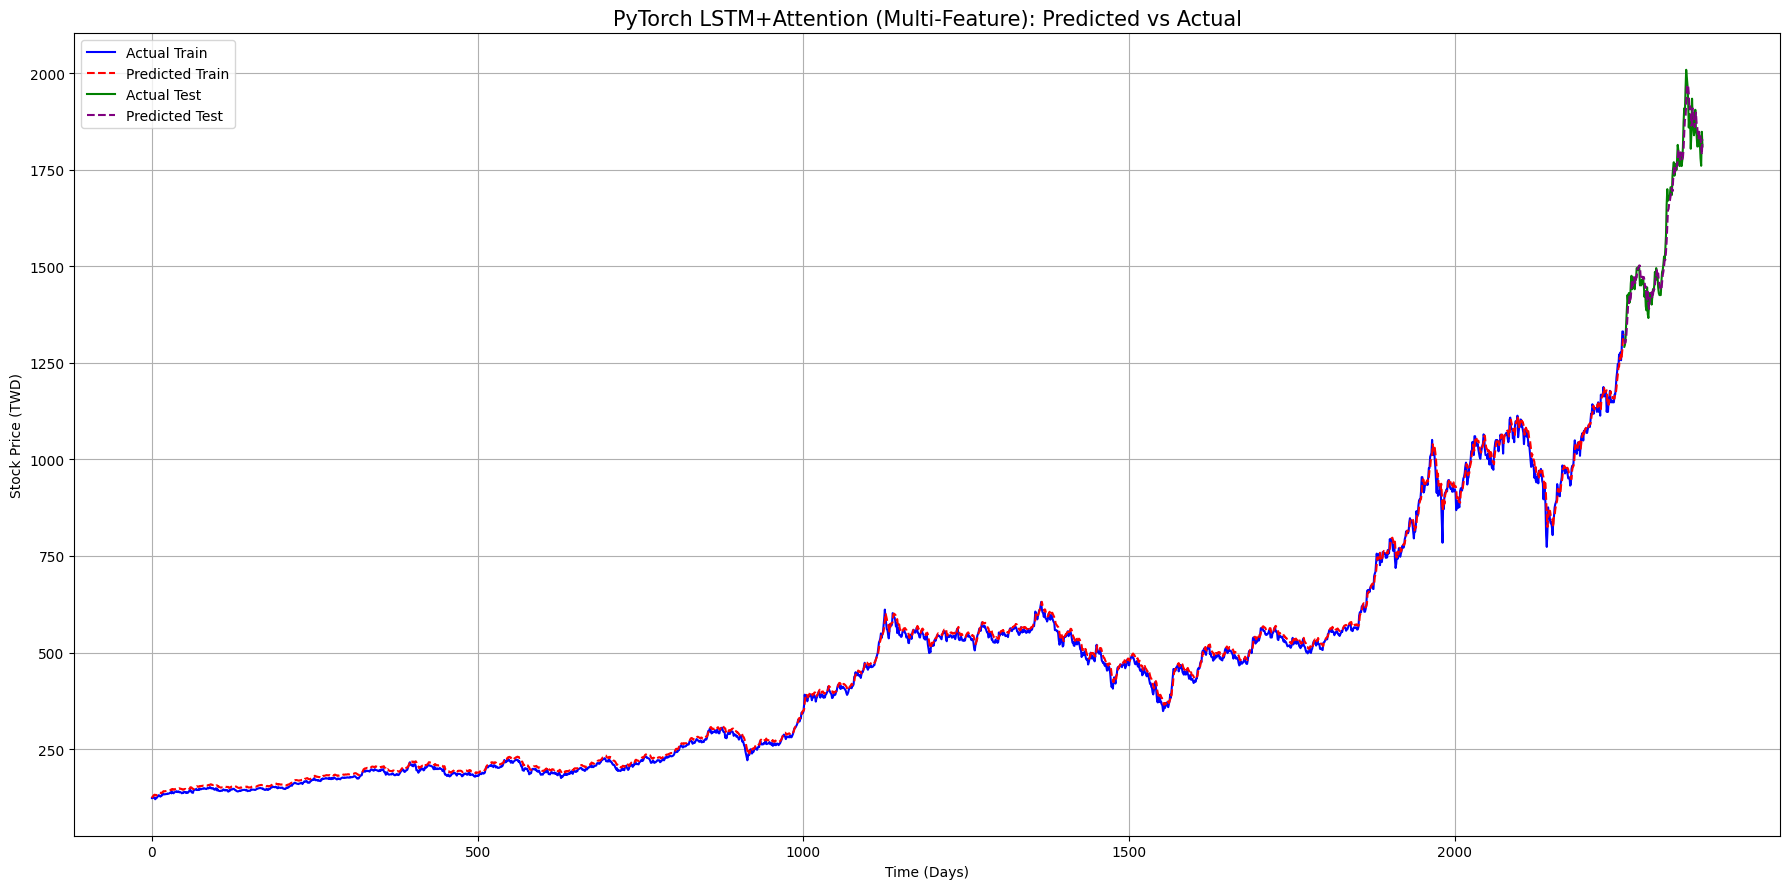

In [12]:
fig, ax = plt.subplots(figsize=(18, 9))

ax.plot(y_train_inv,  label='Actual Train',     color='blue',   linewidth=1.5)
ax.plot(train_pred,   label='Predicted Train',  color='red',    linestyle='--', linewidth=1.5)

test_idx = range(len(y_train_inv), len(y_train_inv) + len(y_test_inv))
ax.plot(test_idx, y_test_inv, label='Actual Test',      color='green',  linewidth=1.5)
ax.plot(test_idx, test_pred,  label='Predicted Test',   color='purple', linestyle='--', linewidth=1.5)

ax.set_title('PyTorch LSTM+Attention (Multi-Feature): Predicted vs Actual', fontsize=15)
ax.set_xlabel('Time (Days)'); ax.set_ylabel('Stock Price (TWD)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True)
plt.tight_layout(); plt.show()

## Step 13：預測下一日收盤價（用於交易決策）

In [13]:
def predict_next_price(raw_feat_values, model, look_back, prev_smoothed_pred=None):
    """
    raw_feat_values: (T, 7) 未正規化，欄位順序同 raw_feat
    回傳：下一日預測收盤價（TWD）
    """
    if len(raw_feat_values) < look_back + 1:
        print('資料不足！'); return None

    close_window   = raw_feat_values[-(look_back + 1):, 0]
    log_ret_window = np.concatenate([[0.0],
        np.log(close_window[1:] / (close_window[:-1] + 1e-10))])
    log_ret_norm   = (log_ret_window - lr_mean) / lr_std

    window_raw  = raw_feat_values[-look_back:]
    window_norm = normalize_set(window_raw, log_ret_norm[-look_back:])

    x = torch.tensor(window_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        pred_resid = model(x).item()
    pred_resid = float(pred_resid * INFER_RESIDUAL_DAMP)

    last_ret_norm = float(window_norm[-1, 0])
    pred_next_ret = pred_resid + last_ret_norm
    pred_next_ret = float(np.clip(pred_next_ret, MIN_NEXT_RET_NORM, MAX_NEXT_RET_NORM))
    pred_lr       = pred_next_ret * lr_std + lr_mean
    pred_lr       = float(np.clip(pred_lr, MIN_DAILY_LOGRET, MAX_DAILY_LOGRET))

    last_close = float(raw_feat_values[-1, 0])
    raw_pred   = last_close * np.exp(pred_lr)

    # naive 與校準後處理：壓低極端預測，讓 RMSE 更穩定
    prev_close = float(raw_feat_values[-2, 0])
    prev_lr    = np.log(last_close / (prev_close + 1e-10))
    naive_pred = last_close * np.exp(np.clip(prev_lr, MIN_DAILY_LOGRET, MAX_DAILY_LOGRET))
    final_pred = postprocess_price(
        raw_pred, last_close, naive_pred,
        blend_lambda=POST_BLEND_LAMBDA,
        shrink_alpha=POST_SHRINK_ALPHA,
        bias_twd=POST_BIAS_TWD,
        max_move_twd=POST_MAX_MOVE_TWD,
        path_smooth_beta=PATH_SMOOTH_BETA,
        path_max_step_twd=PATH_MAX_STEP_TWD
    )
    if prev_smoothed_pred is not None:
        final_pred = PATH_SMOOTH_BETA * float(final_pred) + (1.0 - PATH_SMOOTH_BETA) * float(prev_smoothed_pred)
        final_pred = float(np.clip(final_pred,
                                  float(prev_smoothed_pred) - PATH_MAX_STEP_TWD,
                                  float(prev_smoothed_pred) + PATH_MAX_STEP_TWD))
    return float(final_pred)


today_idx   = len(raw_feat) - 1
today_date  = raw_feat.index[today_idx].date()
today_price = float(raw_feat['Close'].iloc[today_idx])

pred_price  = predict_next_price(raw_feat.values, model, LOOK_BACK)
pred_return = (pred_price - today_price) / today_price

print('=' * 60)
print(f'  日期        : {today_date}')
print(f'  今日收盤價  : {today_price:,.0f} TWD')
print(f'  預測明日價  : {pred_price:,.0f} TWD')
print(f'  預測報酬率  : {pred_return*100:+.2f}%')
print('=' * 60)


  日期        : 2026-04-02
  今日收盤價  : 1,810 TWD
  預測明日價  : 1,801 TWD
  預測報酬率  : -0.47%


## Step 15：Rolling Forecast — 逐日滾動預測

Day  1 (2026-03-20) | Actual:    1840 (   -10) | Pred:    1839 (   -11) | Error:   -1.09 
Day  2 (2026-03-23) | Actual:    1810 (   -30) | Pred:    1839 (    +0) | Error:  +29.40 
Day  3 (2026-03-24) | Actual:    1810 (    +0) | Pred:    1827 (   -12) | Error:  +17.43 
Day  4 (2026-03-25) | Actual:    1845 (   +35) | Pred:    1822 (    -5) | Error:  -22.65 
Day  5 (2026-03-26) | Actual:    1840 (    -5) | Pred:    1835 (   +12) | Error:   -5.42 
Day  6 (2026-03-27) | Actual:    1820 (   -20) | Pred:    1837 (    +2) | Error:  +17.05 
Day  7 (2026-03-30) | Actual:    1780 (   -40) | Pred:    1830 (    -7) | Error:  +50.29 
Day  8 (2026-03-31) | Actual:    1760 (   -20) | Pred:    1810 (   -20) | Error:  +50.12 
Day  9 (2026-04-01) | Actual:    1855 (   +95) | Pred:    1792 (   -18) | Error:  -63.21 
Day 10 (2026-04-02) | Actual:    1810 (   -45) | Pred:    1819 (   +28) | Error:   +9.42 

Rolling RMSE: 33.3583  |  Rolling MAPE: 1.47%
Naive   RMSE: 64.2437  |  Naive   MAPE: 2.65%
✓ 模型優於 

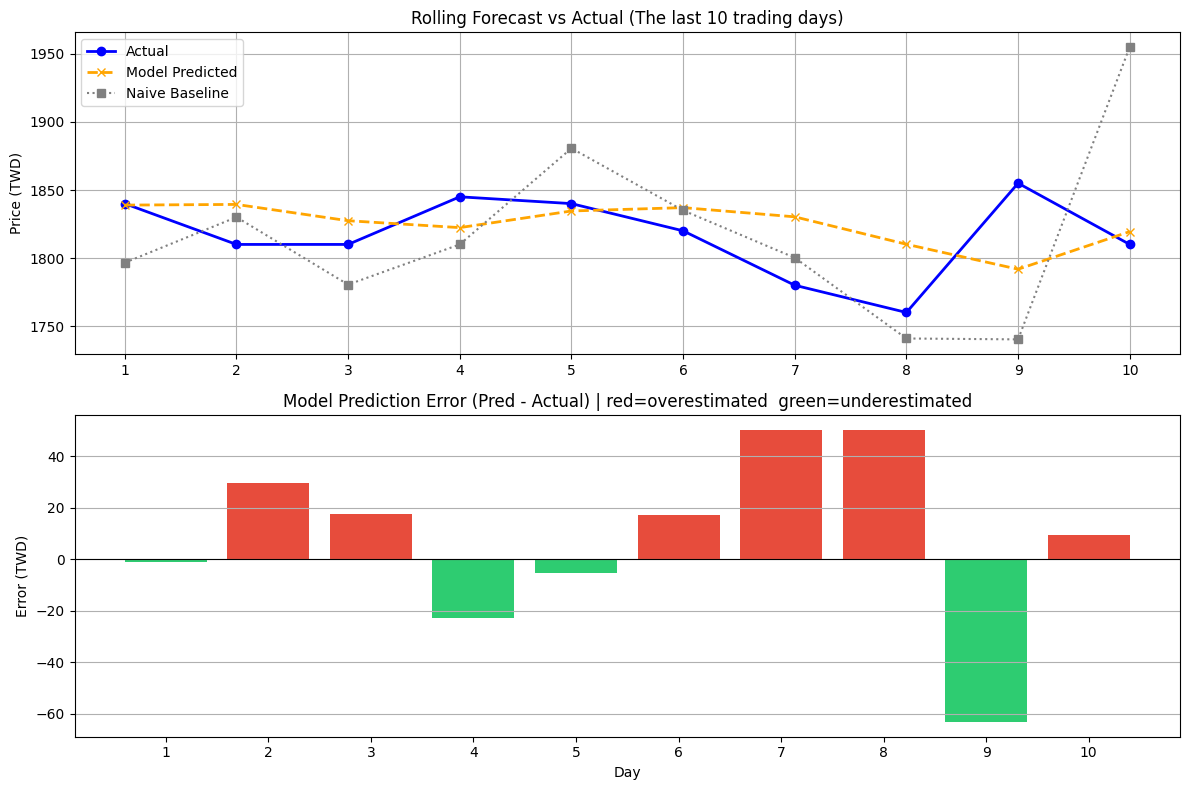

In [25]:
## Step 15：Rolling Forecast — 逐日滾動預測（最近 N 日回測）
# ─────────────────────────────────────────────────────────────────
# 邏輯：
#   1. 從 raw_feat 最後 N_ROLLING 筆之前開始
#   2. 每次用前 LOOK_BACK 筆「原始特徵」預測下一日收盤價
#   3. 增加 naive baseline（直接延續前一天報酬）作比較
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

N_ROLLING    = 10   # 回測最近幾個交易日
total_rows   = len(raw_feat)
roll_start   = total_rows - N_ROLLING   # 滾動預測起始位置（在 raw_feat 的 index）

rolling_preds, rolling_actuals, naive_preds = [], [], []
prev_smooth_pred = None

for day in range(N_ROLLING):
    cur_idx = roll_start + day   # 當日在 raw_feat 的位置

    # 用 cur_idx 之前的資料預測 cur_idx 這天
    history_raw = raw_feat.values[:cur_idx]   # 不含當日，只看「已知」資料
    pred_price  = predict_next_price(history_raw, model, LOOK_BACK, prev_smoothed_pred=prev_smooth_pred)
    prev_smooth_pred = pred_price

    # naive baseline: 假設「明日報酬 = 昨日報酬」
    prev_close = float(raw_feat['Close'].iloc[cur_idx - 1])
    prev_prev_close = float(raw_feat['Close'].iloc[cur_idx - 2]) if cur_idx - 2 >= 0 else prev_close
    prev_log_ret = np.log(prev_close / (prev_prev_close + 1e-10))
    naive_price = prev_close * np.exp(prev_log_ret)

    actual_price = float(raw_feat['Close'].iloc[cur_idx])
    rolling_preds.append(pred_price)
    rolling_actuals.append(actual_price)
    naive_preds.append(naive_price)

    prev_pred   = rolling_preds[day - 1] if day > 0 else prev_close
    chg_actual  = actual_price - prev_close
    chg_pred    = pred_price   - prev_pred
    error       = pred_price   - actual_price


    print(f'Day {day+1:2d} ({raw_feat.index[cur_idx].date()}) | '
          f'Actual: {actual_price:7.0f} ({chg_actual:+6.0f}) | '
          f'Pred: {pred_price:7.0f} ({chg_pred:+6.0f}) | '
          f'Error: {error:+7.2f} ')

rolling_rmse = np.sqrt(mean_squared_error(rolling_actuals, rolling_preds))
rolling_mape = np.mean(np.abs((np.array(rolling_actuals) - np.array(rolling_preds))
                               / np.array(rolling_actuals))) * 100

naive_rmse = np.sqrt(mean_squared_error(rolling_actuals, naive_preds))
naive_mape = np.mean(np.abs((np.array(rolling_actuals) - np.array(naive_preds))
                             / np.array(rolling_actuals))) * 100

print(f'\nRolling RMSE: {rolling_rmse:.4f}  |  Rolling MAPE: {rolling_mape:.2f}%')
print(f'Naive   RMSE: {naive_rmse:.4f}  |  Naive   MAPE: {naive_mape:.2f}%')
if rolling_rmse < naive_rmse:
    print('✓ 模型優於 naive')
else:
    print('⚠ 目前仍接近 naive，建議增加 regime/多週期特徵或調整 loss')

# ── 視覺化 ───────────────────────────────────────────────────────
days = list(range(1, N_ROLLING + 1))
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(days, rolling_actuals, marker='o', color='blue',   linewidth=2, label='Actual')
axes[0].plot(days, rolling_preds,   marker='x', color='orange', linewidth=2,
             linestyle='--', label='Model Predicted')
axes[0].plot(days, naive_preds,     marker='s', color='gray', linewidth=1.5,
             linestyle=':', label='Naive Baseline')
axes[0].set_title(f'Rolling Forecast vs Actual (The last {N_ROLLING} trading days)')
axes[0].set_ylabel('Price (TWD)'); axes[0].legend(); axes[0].grid(True)
axes[0].set_xticks(days)

errors = [p - a for p, a in zip(rolling_preds, rolling_actuals)]
colors = ['#e74c3c' if e > 0 else '#2ecc71' for e in errors]
axes[1].bar(days, errors, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Model Prediction Error (Pred - Actual) | red=overestimated  green=underestimated')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Error (TWD)')
axes[1].set_xticks(days); axes[1].grid(True, axis='y')

plt.tight_layout(); plt.show()


## Step 14：交易策略 & 績效回報

In [31]:
# ╔══════════════════════════════════════════════════════════╗
# ║           ★ 每次執行前請在這裡填入當前狀態 ★              ║
# ╚══════════════════════════════════════════════════════════╝

CURRENT_CASH    = 10_425_840    # ← 目前現金餘額
CURRENT_SHARES  = 6          # ← 目前持股數量
INITIAL_CAPITAL = 10_000_000   # ← 期初資本（通常不動）

# ── 動態門檻參數 ──────────────────────────────────────────────────
# 門檻計算基準：模型預測的 next log_return（由 residual 還原）std
BUY_K          = 0.6    # 買入門檻倍率
SELL_K         = 0.6    # 賣出門檻倍率
PROBE_K        = 0.25   # 弱訊號試單門檻倍率（比 BUY_K 低）
TRADE_RATIO    = 0.35   # 強訊號：35% 資金/持股
PROBE_RATIO    = 0.12   # 弱訊號試單：12% 資金/持股
WINDOW_K       = LOOK_BACK

# ── 正確計算動態門檻（residual -> next return）────────────────────
_test_pred_ret_norm = test_pred_resid[-WINDOW_K:] + last_ret_test[-WINDOW_K:]
_test_pred_ret_norm = np.clip(_test_pred_ret_norm, MIN_NEXT_RET_NORM, MAX_NEXT_RET_NORM)
_test_pred_lr       = _test_pred_ret_norm * lr_std + lr_mean
_test_pred_lr       = np.clip(_test_pred_lr, MIN_DAILY_LOGRET, MAX_DAILY_LOGRET)
_pred_std           = float(np.std(_test_pred_lr))   # 通常在 0.003~0.010 量級

BUY_THRESHOLD  =  _pred_std * BUY_K
SELL_THRESHOLD = -_pred_std * SELL_K
PROBE_BUY_THR  =  _pred_std * PROBE_K
PROBE_SELL_THR = -_pred_std * PROBE_K

# ── 初始化 portfolio ──────────────────────────────────────────────
portfolio = {
    'cash'               : CURRENT_CASH,
    'shares'             : CURRENT_SHARES,
    'total_asset_history': [],
}
trading_log = []

latest_price  = float(raw_feat['Close'].iloc[-1])
current_total = CURRENT_CASH + CURRENT_SHARES * latest_price

print('═' * 60)
print(f'  現金餘額    : {CURRENT_CASH:>15,.0f} TWD')
print(f'  持股數量    : {CURRENT_SHARES:>15,} 股')
print(f'  最新股價    : {latest_price:>15,.0f} TWD')
print(f'  股票市值    : {CURRENT_SHARES * latest_price:>15,.0f} TWD')
print(f'  {"─"*52}')
print(f'  當前總資產  : {current_total:>15,.0f} TWD')
print(f'  期初資本    : {INITIAL_CAPITAL:>15,.0f} TWD')
print(f'  ROI  : {(current_total-INITIAL_CAPITAL)/INITIAL_CAPITAL*100:>+14.2f}%')
print(f'  {"─"*52}')
print(f'  模型預測 next log_ret std : {_pred_std*100:.4f}%')
print(f'  強訊號買入門檻 (×{BUY_K})  : {BUY_THRESHOLD*100:>+.4f}%')
print(f'  強訊號賣出門檻 (×{SELL_K})  : {SELL_THRESHOLD*100:>+.4f}%')
print(f'  弱訊號試單門檻 (×{PROBE_K}) : ±{PROBE_BUY_THR*100:.4f}%')
print('═' * 60)


def make_decision(today_price, pred_price, portfolio, is_last_day=False,
                  buy_thr=None, sell_thr=None,
                  probe_buy_thr=None, probe_sell_thr=None):
    """
    三層決策：
    1) 強訊號（> buy_thr）  → BUY / SELL（35%）
    2) 弱訊號（> probe_thr）→ BUY probe / SELL probe（12%）
    3) 雜訊（< probe_thr）  → HOLD
    """
    b_thr  = buy_thr        if buy_thr        is not None else BUY_THRESHOLD
    s_thr  = sell_thr       if sell_thr       is not None else SELL_THRESHOLD
    pb_thr = probe_buy_thr  if probe_buy_thr  is not None else PROBE_BUY_THR
    ps_thr = probe_sell_thr if probe_sell_thr is not None else PROBE_SELL_THR

    pred_return = (pred_price - today_price) / today_price

    if is_last_day:
        if portfolio['shares'] > 0:
            revenue = portfolio['shares'] * today_price
            portfolio['cash'] += revenue
            s = portfolio['shares']; portfolio['shares'] = 0
            return 'SELL (force liquidate)', s, revenue
        return 'HOLD', 0, 0

    # ── 強訊號 ─────────────────────────────────────────────────────
    if pred_return > b_thr:
        budget = portfolio['cash'] * TRADE_RATIO
        shares = int(budget // today_price)
        if shares >= 1:
            cost = shares * today_price
            portfolio['cash'] -= cost; portfolio['shares'] += shares
            return 'BUY', shares, cost

    if pred_return < s_thr:
        shares = int(portfolio['shares'] * TRADE_RATIO)
        if shares < 1: shares = portfolio['shares']
        if shares >= 1:
            revenue = shares * today_price
            portfolio['cash'] += revenue; portfolio['shares'] -= shares
            return 'SELL', shares, revenue

    # ── 弱訊號試單 ─────────────────────────────────────────────────
    if pred_return > pb_thr:
        budget = portfolio['cash'] * PROBE_RATIO
        shares = int(budget // today_price)
        if shares >= 1:
            cost = shares * today_price
            portfolio['cash'] -= cost; portfolio['shares'] += shares
            return 'BUY (probe)', shares, cost

    if pred_return < ps_thr:
        shares = int(portfolio['shares'] * PROBE_RATIO)
        if shares < 1: shares = min(1, portfolio['shares'])
        if shares >= 1:
            revenue = shares * today_price
            portfolio['cash'] += revenue; portfolio['shares'] -= shares
            return 'SELL (probe)', shares, revenue

    return 'HOLD', 0, 0


print('Trading functions defined.')


════════════════════════════════════════════════════════════
  現金餘額    :      10,425,840 TWD
  持股數量    :               6 股
  最新股價    :           1,810 TWD
  股票市值    :          10,860 TWD
  ────────────────────────────────────────────────────
  當前總資產  :      10,436,700 TWD
  期初資本    :      10,000,000 TWD
  ROI  :          +4.37%
  ────────────────────────────────────────────────────
  模型預測 next log_ret std : 1.8244%
  強訊號買入門檻 (×0.6)  : +1.0947%
  強訊號賣出門檻 (×0.6)  : -1.0947%
  弱訊號試單門檻 (×0.25) : ±0.4561%
════════════════════════════════════════════════════════════
Trading functions defined.


In [32]:
# ════════════════════════════════════════════════════════
# ★ 最後一天（4/2）把 IS_FINAL_DAY 改成 True
# ════════════════════════════════════════════════════════
IS_FINAL_DAY = True

today_idx   = len(raw_feat) - 1
today_date  = raw_feat.index[today_idx].date()
today_price = float(raw_feat['Close'].iloc[today_idx])

pred_price  = predict_next_price(raw_feat.values, model, LOOK_BACK)
pred_return = (pred_price - today_price) / today_price

action, shares_traded, amount = make_decision(
    today_price, pred_price, portfolio, is_last_day=IS_FINAL_DAY)

total_asset = portfolio['cash'] + portfolio['shares'] * today_price
portfolio['total_asset_history'].append(total_asset)
trading_log.append({
    'Date': today_date, 'Actual Price': round(today_price, 2),
    'Pred Price': round(pred_price, 2),
    'Pred Return': f'{pred_return*100:+.2f}%',
    'Action': action, 'Shares Traded': shares_traded,
    'Amount (TWD)': round(amount),
    'Cash Balance': round(portfolio['cash']),
    'Holdings': portfolio['shares'],
    'Total Asset': round(total_asset),
})

print('=' * 60)
print(f'  日期        : {today_date}')
print(f'  今日收盤價  : {today_price:,.0f} TWD')
print(f'  預測明日價  : {pred_price:,.0f} TWD')
print(f'  預測報酬率  : {pred_return*100:+.2f}%')
print('─' * 60)
print(f'  ★ 決策      : {action}')
if shares_traded > 0:
    print(f'  交易股數    : {shares_traded:,} 股')
    print(f'  交易金額    : {amount:,.0f} TWD')
print('─' * 60)
print(f'  現金餘額    : {portfolio["cash"]:>15,.0f} TWD')
print(f'  持股數量    : {portfolio["shares"]:>15,} 股')
print(f'  總資產      : {total_asset:>15,.0f} TWD')
print('=' * 60)


  日期        : 2026-04-02
  今日收盤價  : 1,810 TWD
  預測明日價  : 1,801 TWD
  預測報酬率  : -0.47%
────────────────────────────────────────────────────────────
  ★ 決策      : SELL (force liquidate)
  交易股數    : 6 股
  交易金額    : 10,860 TWD
────────────────────────────────────────────────────────────
  現金餘額    :      10,436,700 TWD
  持股數量    :               0 股
  總資產      :      10,436,700 TWD


In [33]:
if trading_log:
    log_df = pd.DataFrame(trading_log)
    print('\n── Trading Log ──────────────────────────────────────────────')
    print(log_df.to_string(index=False))

    final_asset = portfolio['cash'] + portfolio['shares'] * float(raw_feat['Close'].iloc[-1])
    roi  = (final_asset - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    assets = portfolio['total_asset_history']
    peak, max_dd = assets[0], 0
    for a in assets:
        if a > peak: peak = a
        dd = (peak - a) / peak
        if dd > max_dd: max_dd = dd

    print(f'\n── Performance ──────────────────────────────────────────────')
    print(f'  ROI          : {roi:+.2f}%')
    print(f'  Max Drawdown : {max_dd*100:.2f}%')

    if len(assets) > 1:
        dates = [r['Date'] for r in trading_log]
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        axes[0].plot(dates, assets, marker='o', color='steelblue', linewidth=2)
        axes[0].axhline(INITIAL_CAPITAL, color='gray', linestyle='--', label='Initial')
        axes[0].set_title(f'Asset Curve | ROI: {roi:+.2f}% | Max DD: {max_dd*100:.2f}%')
        axes[0].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
        axes[0].legend(); axes[0].grid(True)

        axes[1].plot(dates, [r['Actual Price'] for r in trading_log],
                     marker='o', color='blue', label='Actual')
        axes[1].plot(dates, [r['Pred Price'] for r in trading_log],
                     marker='x', color='orange', linestyle='--', label='Predicted')
        for r in trading_log:
            if 'BUY' in r['Action']:
                axes[1].annotate('B', (r['Date'], r['Actual Price']),
                    xytext=(0, -18), textcoords='offset points',
                    color='green', fontweight='bold', ha='center')
            elif 'SELL' in r['Action']:
                axes[1].annotate('S', (r['Date'], r['Actual Price']),
                    xytext=(0, 10), textcoords='offset points',
                    color='red', fontweight='bold', ha='center')
        axes[1].set_title('Predicted vs Actual (B=Buy, S=Sell)')
        axes[1].legend(); axes[1].grid(True)
        plt.xticks(rotation=30); plt.tight_layout(); plt.show()
else:
    print('No trades recorded yet.')


── Trading Log ──────────────────────────────────────────────
      Date  Actual Price  Pred Price Pred Return                 Action  Shares Traded  Amount (TWD)  Cash Balance  Holdings  Total Asset
2026-04-02        1810.0      1801.4      -0.47% SELL (force liquidate)              6         10860      10436700         0     10436700

── Performance ──────────────────────────────────────────────
  ROI          : +4.37%
  Max Drawdown : 0.00%


## Step 16：未來 10 日逐日 ROI 模擬

未來 10 日 ROI 模擬  (* = 以預測價估算，非真實成交)
────────────────────────────────────────────────────────────────────────────────────────────
Day   預測收盤  預測報酬  買入門檻  決策                    持股        現金       總資產*    ROI*
────────────────────────────────────────────────────────────────────────────────────────────
D+1       1,801   -0.475%  +1.0907%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+2       1,802   +0.013%  +1.0718%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+3       1,803   +0.058%  +1.0717%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+4       1,804   +0.062%  +1.0545%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+5       1,805   +0.063%  +1.0384%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+6       1,806   +0.063%  +1.0369%  HOLD                        0    10,436,700   10,436,700    +4.37%
D+7       1,807   +0.063%  +1.0116%  HOLD                        0    10,436,

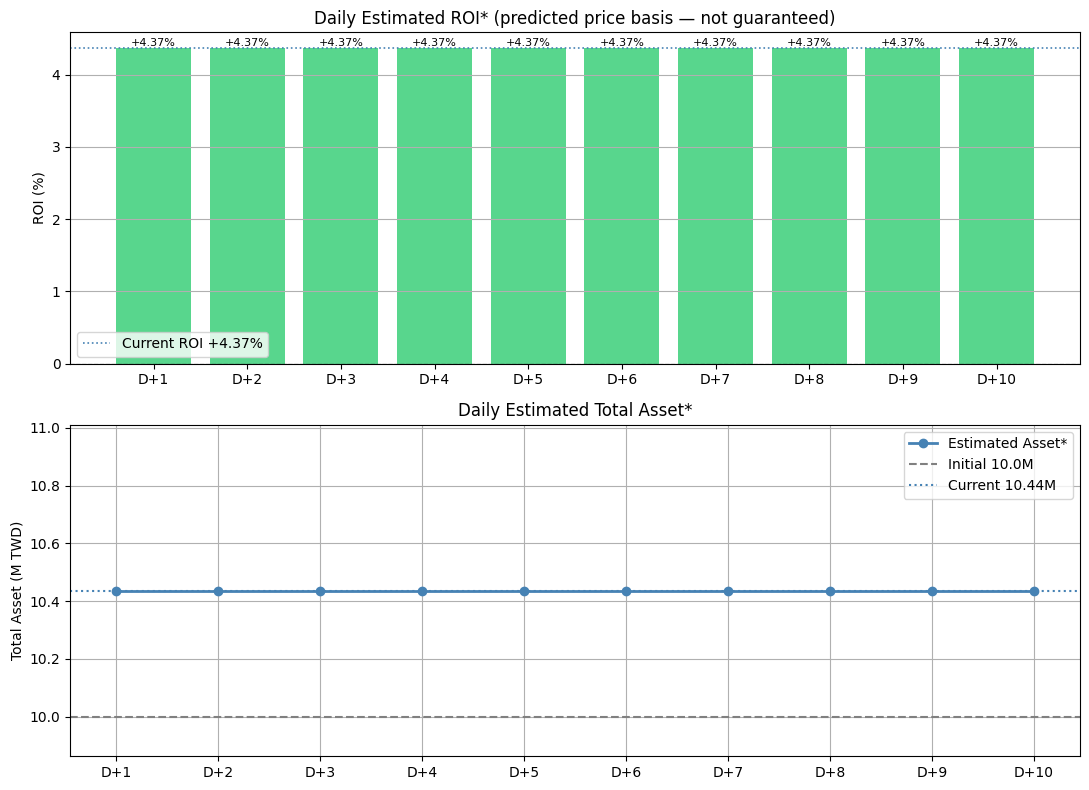

In [34]:
# ══════════════════════════════════════════════════════════════
# Step 16：未來 10 日逐日 ROI 模擬（動態門檻版）
# 注意：所有 ROI 均為模型預測估算，非真實成交保證值
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

N_FUTURE = 10

sim_portfolio = {'cash': portfolio['cash'], 'shares': portfolio['shares']}
sim_raw       = raw_feat.values.copy()
sim_close     = float(raw_feat['Close'].iloc[-1])
sim_prev_pred = None

# EWM 初始化（RSI / MACD 近似更新）
_closes   = raw_feat['Close'].values
_ema12    = float(pd.Series(_closes).ewm(span=12, adjust=False).mean().iloc[-1])
_ema26    = float(pd.Series(_closes).ewm(span=26, adjust=False).mean().iloc[-1])
_diff_s   = pd.Series(_closes).diff().dropna()
_avg_gain = float(_diff_s.clip(lower=0).ewm(com=13, min_periods=14).mean().iloc[-1])
_avg_loss = float((-_diff_s).clip(lower=0).ewm(com=13, min_periods=14).mean().iloc[-1])
alpha12   = 2 / 13;  alpha26 = 2 / 27

# 動態門檻滾動更新用的 log_return 歷史
_pred_lr_history = list(_test_pred_lr[-WINDOW_K:])

day_labels, roi_history, asset_history = [], [], []

header = ('Day   預測收盤  預測報酬  買入門檻  決策                    '
          '持股        現金       總資產*    ROI*')
print('未來 10 日 ROI 模擬  (* = 以預測價估算，非真實成交)')
print('─' * 92)
print(header)
print('─' * 92)

for day in range(1, N_FUTURE + 1):
    pred_price = predict_next_price(sim_raw, model, LOOK_BACK, prev_smoothed_pred=sim_prev_pred)
    if pred_price is None:
        print(f'Day {day}: 資料不足，停止模擬'); break
    sim_prev_pred = pred_price

    pred_return = (pred_price - sim_close) / sim_close

    # 動態門檻：用滾動預測 log_return 的 std
    _cur_pred_lr = np.log(pred_price / (sim_close + 1e-10))
    _pred_lr_history.append(_cur_pred_lr)
    if len(_pred_lr_history) > WINDOW_K:
        _pred_lr_history.pop(0)
    cur_std       = float(np.std(_pred_lr_history)) if len(_pred_lr_history) >= 3 else _pred_std
    dyn_buy_thr   = cur_std * BUY_K
    dyn_sell_thr  = -cur_std * SELL_K
    dyn_pb_thr    = cur_std * PROBE_K
    dyn_ps_thr    = -cur_std * PROBE_K

    is_last = (day == N_FUTURE)
    action, shares_traded, amount = make_decision(
        sim_close, pred_price, sim_portfolio, is_last_day=is_last,
        buy_thr=dyn_buy_thr, sell_thr=dyn_sell_thr,
        probe_buy_thr=dyn_pb_thr, probe_sell_thr=dyn_ps_thr)

    est_total = sim_portfolio['cash'] + sim_portfolio['shares'] * pred_price
    roi_day   = (est_total - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100

    line = (f'D+{day:<2}  {pred_price:>9,.0f}  {pred_return*100:>+7.3f}%'
            f'  {dyn_buy_thr*100:>+7.4f}%  {action:<22}'
            f'  {sim_portfolio["shares"]:>5,}'
            f'  {sim_portfolio["cash"]:>12,.0f}'
            f'  {est_total:>11,.0f}'
            f'  {roi_day:>+7.2f}%')
    print(line)

    day_labels.append(f'D+{day}')
    roi_history.append(roi_day)
    asset_history.append(est_total)

    # 更新特徵序列（EWM 近似 RSI/MACD）
    prev_close  = sim_close;  sim_close = pred_price
    new_log_ret = np.log(sim_close / (prev_close + 1e-10))
    _ema12 = alpha12 * sim_close + (1 - alpha12) * _ema12
    _ema26 = alpha26 * sim_close + (1 - alpha26) * _ema26
    new_macd = _ema12 - _ema26
    delta = sim_close - prev_close
    _avg_gain = (1/14) * max(delta, 0) + (13/14) * _avg_gain
    _avg_loss = (1/14) * max(-delta, 0) + (13/14) * _avg_loss
    new_rsi = 100 - 100 / (1 + _avg_gain / (_avg_loss + 1e-10))
    last_row    = sim_raw[-1].copy()
    last_row[0] = sim_close;  last_row[1] = new_rsi;  last_row[2] = new_macd
    last_row[5] = float(np.clip(new_log_ret, -0.1, 0.1))
    # Week_trend（col 6）：用最近 5 步預測的累積 log_return 近似
    if len(_pred_lr_history) >= 5:
        last_row[6] = float(np.clip(sum(_pred_lr_history[-5:]), -0.15, 0.15))
    sim_raw = np.vstack([sim_raw, last_row])

print('─' * 92)
if roi_history:
    print(f'\n  模擬期末預估 ROI*   : {roi_history[-1]:+.2f}%  （預測估算，非保證值）')
    print(f'  模擬期末預估總資產* : {asset_history[-1]:,.0f} TWD')
    print(f'  ⚠ 以上 ROI 全為預測估算，實際績效以真實收盤成交為準')

if roi_history:
    fig, axes = plt.subplots(2, 1, figsize=(11, 8))   # 改 figsize，解決 tight_layout warning

    bar_colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in roi_history]
    axes[0].bar(day_labels, roi_history, color=bar_colors, alpha=0.8)
    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ref_roi = (current_total - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    axes[0].axhline(ref_roi, color='steelblue', linewidth=1.2, linestyle=':',
                    label=f'Current ROI {ref_roi:+.2f}%')
    for i, v in enumerate(roi_history):
        axes[0].text(i, v + (0.03 if v >= 0 else -0.08),
                     f'{v:+.2f}%', ha='center', fontsize=8)
    axes[0].set_title('Daily Estimated ROI* (predicted price basis — not guaranteed)')
    axes[0].set_ylabel('ROI (%)'); axes[0].legend(); axes[0].grid(True, axis='y')

    axes[1].plot(day_labels, [a / 1e6 for a in asset_history],
                 marker='o', color='steelblue', linewidth=2, label='Estimated Asset*')
    axes[1].axhline(INITIAL_CAPITAL / 1e6, color='gray', linestyle='--',
                    label=f'Initial {INITIAL_CAPITAL/1e6:.1f}M')
    axes[1].axhline(current_total / 1e6, color='steelblue', linestyle=':',
                    label=f'Current {current_total/1e6:.2f}M')
    axes[1].set_title('Daily Estimated Total Asset*')
    axes[1].set_ylabel('Total Asset (M TWD)'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout(); plt.show()
